In [85]:
# Makes sure that the notebook is reloaded when changes are made to other files in the project
%load_ext autoreload
%autoreload 2

import sys

# check if i am running in the same python environment as vscode
terminal_venv = '/Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/venv/bin/python'
if sys.executable == terminal_venv:
    print(f"Running in the same python environment as vscode\n{sys.executable}")
else:
    print(f"Running in a different python environment than vscode\n{sys.executable}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Running in the same python environment as vscode
/Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/venv/bin/python


In [ ]:
import torch
import matplotlib.pyplot as plt

from physics.residuals import pde_loss_fn, bc_loss_fn, ic_loss_fn
from core.data import PINNDataset
from core.model import PINN, pinn_coefficients
from core.solver import PINNSolver


# set the experiment seed
exp_seed = 42
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f' --- Starting experiment on device {device}')
# instantiate the solver
solver = PINNSolver(neurons=20, layers=6, n_pde=2000, pde_loss_fn=pde_loss_fn, bc_loss_fn=bc_loss_fn, ic_loss_fn=ic_loss_fn, device=device, seed=exp_seed)

# plot dataset
solver.pde_training_dataset.plotme()

# training pipeline
# train simple adam for some epochs
solver.train_adam(method='vanilla', epochs=10000)

# # fine tune with dynamic weight algorithm
# solver.train_adam(method='dynweight', epochs=15000, update_weights_every=20, wait_until=5000)

# # further fine-tune with adaptive resampling
# solver.train_adam(epochs=30000, problem_type='forward', method='adaptive_resampling', accumulate=False, rard_sample_size=500, resample_every=500, wait_until=5000)
# # plot residual maps
# # plot new dataset

# # train for some epochs with simple adam
# solver.train_adam(method='vanilla', epochs=5000)

# # final fine tuning with lbfgs algorithm - freeze dynamic weight here.
# solver.train_lbfgs(epochs=300, problem_type='forward')

# vizualization of the 2d concentrations
solver.vizualize_prediction('cf', [0, 6, 12, 18, 24])

# # vizualization of losses



In [91]:
from core.context import PhysicsContext

cfg = {
    # physical scale constants
    'R': 200,
    'tau': 50,
    'C0': 60,
    # pde parameters
    'd': 8.38,
    'k_off': 4e-3,
    'k_d': 6.76,
    'k_int': 1.4e-5,
    'r_t': 1060.0,
    'p_up': 2.5e-4,
    'p_cl': 2.6e-1,
    # pde weights
    'eq1': 1.0,
    'eq2': 1.0,
    'eq3': 1.0,
    'center': 1.0,
    'surface': 1.0,
    'ic': 1.0
}  

ctx = PhysicsContext(cfg=cfg)
ctx.get_pde_parameters()
ctx.get_pde_parameters()

{'d': Parameter containing:
 tensor(8.3800),
 'k_d': Parameter containing:
 tensor(6.7600),
 'k_int': Parameter containing:
 tensor(1.4000e-05),
 'k_off': Parameter containing:
 tensor(0.0040),
 'p_cl': Parameter containing:
 tensor(0.2600),
 'p_up': Parameter containing:
 tensor(0.0003),
 'r_t': Parameter containing:
 tensor(1060.)}

{'d': Parameter containing:
 tensor(8.3800, requires_grad=True),
 'k_d': Parameter containing:
 tensor(6.7600, requires_grad=True),
 'k_int': Parameter containing:
 tensor(1.4000e-05, requires_grad=True),
 'k_off': Parameter containing:
 tensor(0.0040, requires_grad=True),
 'p_cl': Parameter containing:
 tensor(0.2600, requires_grad=True),
 'p_up': Parameter containing:
 tensor(0.0003, requires_grad=True),
 'r_t': Parameter containing:
 tensor(1060., requires_grad=True)}

neural network weights initialized succesfully


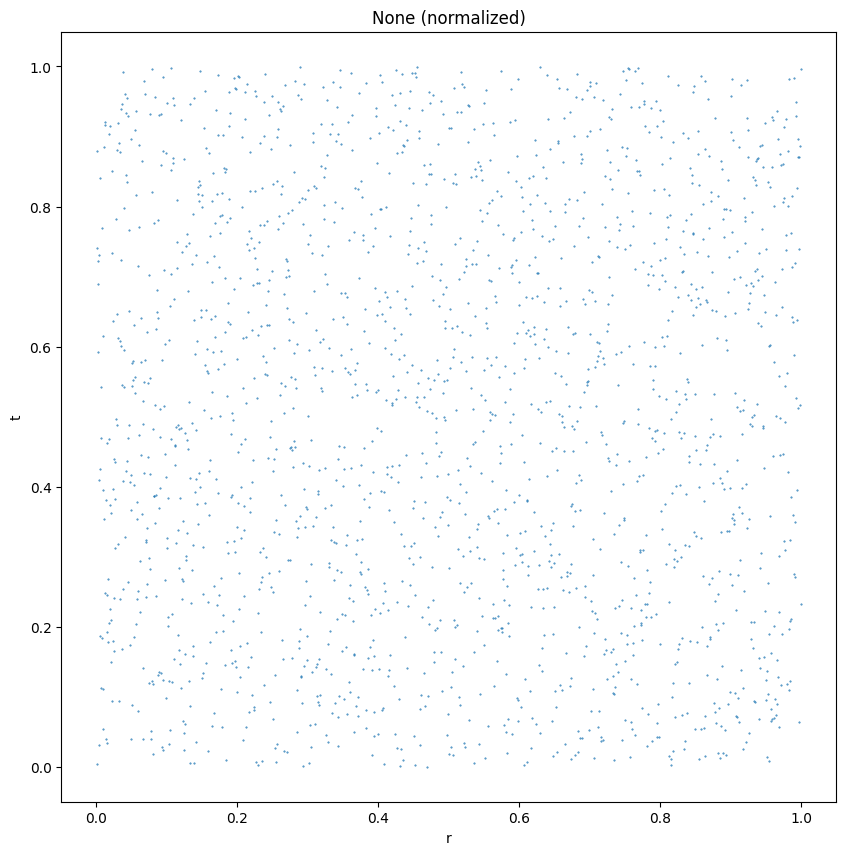

(tensor(2.4787e+09, grad_fn=<MulBackward0>),
 tensor(0.0046, grad_fn=<MulBackward0>),
 tensor(3.5731e-12, grad_fn=<MulBackward0>))

In [75]:
from core.data import DataGenerator


pinn = PINN(n_layers=6, n_neurons=10, seed=42)
generator = DataGenerator()
pde_dataset = PINNDataset(2000, approximator=pinn, generator=generator, sampling_type='lhc')
pde_dataset.plotme()
ctx = PhysicsContext(cfg=cfg)
pde_loss_fn(approximator=pinn, data=pde_dataset, ctx=ctx)

In [ ]:
pinn.physics_context.pde_parameters